# Assignment 4: Decision Tree Model and Business Interpretation
**Course:** MBAI 5310G-001 — AI Programming  
**Institution:** Ontario Tech University  
**Lecturer:** Zahra Atf  
**Dataset:** AdVantage Growth Studio — Marketing Campaign Dataset

---

## Task 1: Understand the Business Problem

**What is the business about?**

AdVantage Growth Studio is a data-driven marketing agency that helps small and
medium-sized businesses design, target, and evaluate marketing campaigns.

The agency uses customer data, campaign engagement data, and sales outcomes to
help clients understand which customers are most likely to respond positively
to a campaign.

Its main goal is to improve campaign conversion rates while reducing wasted
advertising budget.

---

**What problem is the business trying to solve?**

The key business problem is campaign inefficiency. Many businesses spend money
sending campaigns to customers who are unlikely to respond, while also failing
to identify customers who are ready to buy but need the right message or offer.

This creates two problems: wasted marketing budget and missed revenue opportunities.

The agency needs a model that can predict which customers are likely to convert,
and explain the results in a way that non-technical managers can understand
and act on.

---

**What decision can machine learning help the business make?**

Machine learning can help the business decide which customers should receive
follow-up marketing attention after a campaign.

For example, the model can be used to prioritize customers for a discount
reminder, a personalized email, a sales follow-up, or a retargeting advertisement.

It can also help allocate campaign budget across channels such as Email,
Social Media, Search Ads, and SMS based on which channels drive the most
conversions.

---

**What is the target variable in the dataset?**

The target variable is **Converted**.

It is a binary column with two possible values:
- **Yes** — the customer converted after receiving the campaign
- **No** — the customer did not convert

---

**What are the input features?**

The input features are grouped into five categories:

- **Customer demographics:** Age, Annual_Income, Region
- **Customer relationship:** Customer_Segment, Loyalty_Score, Customer_Satisfaction
- **Campaign information:** Campaign_Channel, Campaign_Type, Discount_Offered_Percent, Ad_Exposure_Count
- **Engagement behavior:** Email_Opened, Ad_Clicked, Website_Visits_Last_30_Days, Social_Media_Engagement_Score
- **Purchase history:** Previous_Purchases, Average_Order_Value, Days_Since_Last_Purchase, Prior_Campaign_Response

Note: Customer_ID and Campaign_Date are excluded — Customer_ID is only an
identifier and Campaign_Date is not a meaningful customer characteristic.

---

**Why is this prediction useful for the business?**

The prediction helps the agency focus campaign resources on customers who are
most likely to convert, rather than sending offers to everyone indiscriminately.

This improves campaign efficiency by reducing budget waste on customers who are
unlikely to respond, and increases revenue by ensuring that high-potential
customers receive the right message at the right time.

It also helps managers understand which campaign channels, offer types, and
customer behaviors are most strongly linked to conversion — turning model
results into practical marketing decisions.

## Task 2: Prepare the Data

In [1]:
# Import pandas to work with data tables
import pandas as pd

# Import numpy for numerical operations
import numpy as np

# Import matplotlib to create charts and graphs
import matplotlib.pyplot as plt

# Import display to show tables nicely in the notebook
from IPython.display import display

# Store the file path in a variable
file_path = "/Users/mr_quayci/Downloads/business_plan_marketing_campaign_decision_tree/marketing_campaign_decision_tree_dataset.xlsx"

# Read the Excel file and load it into a pandas DataFrame
df = pd.read_excel(file_path)

# Confirm the dataset loaded successfully
print("Dataset loaded successfully!")

# Print the number of rows and columns
print("Dataset shape:", df.shape)

# Display the first five rows of the dataset
display(df.head())

Dataset loaded successfully!
Dataset shape: (605, 21)


,Customer_ID,Campaign_Date,Age,Annual_Income,Customer_Segment,Region,Campaign_Channel,Campaign_Type,Ad_Exposure_Count,Email_Opened,...,Website_Visits_Last_30_Days,Previous_Purchases,Average_Order_Value,Discount_Offered_Percent,Days_Since_Last_Purchase,Loyalty_Score,Customer_Satisfaction,Social_Media_Engagement_Score,Prior_Campaign_Response,Converted
0,CUST-0001,2026-04-14,36,58196.0,New,British Columbia,Email,Brand Awareness,4,Yes,...,7,1,131.51,20,60,54,5.0,37,No,No
1,CUST-0002,2026-04-24,38,49043.0,Returning,Ontario,Email,Retargeting,5,Yes,...,10,5,27.61,20,73,80,8.0,50,No,No
2,CUST-0003,2026-02-01,21,45952.0,New,Ontario,Email,Discount Offer,4,Yes,...,6,0,104.65,25,39,14,8.0,55,No,Yes
3,CUST-0004,2026-02-28,18,107638.0,Loyal,British Columbia,Search Ads,Retargeting,4,Yes,...,6,12,135.31,20,32,73,7.0,23,No,Yes
4,CUST-0005,2026-03-01,50,89969.0,Returning,Quebec,Search Ads,New Product,1,Yes,...,12,4,27.49,5,5,40,7.0,45,No,No


In [2]:
# Display the last five rows of the dataset
print("Last Five Rows")
print("-" * 50)
display(df.tail())

# Check the number of rows and columns
print("\nDataset Shape")
print("-" * 50)
print(df.shape)

# Show column names, data types, and non-null counts
print("\nData Types")
print("-" * 50)
df.info()

# Count missing values in each column
print("\nMissing Values")
print("-" * 50)
display(df.isnull().sum())

# Count duplicate rows
print("\nDuplicate Rows")
print("-" * 50)
print(df.duplicated().sum())

# Show summary statistics for numerical columns
print("\nSummary Statistics")
print("-" * 50)
display(df.describe())

Last Five Rows
--------------------------------------------------


,Customer_ID,Campaign_Date,Age,Annual_Income,Customer_Segment,Region,Campaign_Channel,Campaign_Type,Ad_Exposure_Count,Email_Opened,...,Website_Visits_Last_30_Days,Previous_Purchases,Average_Order_Value,Discount_Offered_Percent,Days_Since_Last_Purchase,Loyalty_Score,Customer_Satisfaction,Social_Media_Engagement_Score,Prior_Campaign_Response,Converted
600,CUST-0021,2026-04-09,32,83350.0,Loyal,Alberta,Social Media,Retargeting,3,Yes,...,0,7,83.78,30,19,94,8.0,70,No,Yes
601,CUST-0146,2026-03-14,37,23927.0,Loyal,Other,Display Ads,New Product,3,No,...,13,5,82.43,10,33,89,6.0,46,No,No
602,CUST-0323,2026-02-26,34,44103.0,At Risk,Alberta,Social Media,Discount Offer,3,No,...,0,5,25.00,15,136,51,4.0,62,No,No
603,CUST-0451,2026-01-07,29,69998.0,New,Alberta,Social Media,Discount Offer,4,Yes,...,8,1,58.92,15,66,30,7.0,96,No,Yes
604,CUST-0511,2026-03-23,38,89524.0,Returning,British Columbia,Social Media,New Product,2,No,...,0,6,128.75,10,58,34,7.0,63,No,No



Dataset Shape
--------------------------------------------------
(605, 21)

Data Types
--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 605 entries, 0 to 604
Data columns (total 21 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Customer_ID                    605 non-null    object 
 1   Campaign_Date                  605 non-null    object 
 2   Age                            605 non-null    int64  
 3   Annual_Income                  595 non-null    float64
 4   Customer_Segment               599 non-null    object 
 5   Region                         605 non-null    object 
 6   Campaign_Channel               605 non-null    object 
 7   Campaign_Type                  605 non-null    object 
 8   Ad_Exposure_Count              605 non-null    int64  
 9   Email_Opened                   605 non-null    object 
 10  Ad_Clicked                     

Customer_ID                       0
Campaign_Date                     0
Age                               0
Annual_Income                    10
Customer_Segment                  6
Region                            0
Campaign_Channel                  0
Campaign_Type                     0
Ad_Exposure_Count                 0
Email_Opened                      0
Ad_Clicked                        0
Website_Visits_Last_30_Days       0
Previous_Purchases                0
Average_Order_Value               6
Discount_Offered_Percent          0
Days_Since_Last_Purchase          0
Loyalty_Score                     0
Customer_Satisfaction             8
Social_Media_Engagement_Score     0
Prior_Campaign_Response           0
Converted                         0
dtype: int64


Duplicate Rows
--------------------------------------------------
5

Summary Statistics
--------------------------------------------------


,Age,Annual_Income,Ad_Exposure_Count,Website_Visits_Last_30_Days,Previous_Purchases,Average_Order_Value,Discount_Offered_Percent,Days_Since_Last_Purchase,Loyalty_Score,Customer_Satisfaction,Social_Media_Engagement_Score
count,605.000000,595.000000,605.000000,605.000000,605.000000,599.000000,605.000000,605.000000,605.000000,597.000000,605.000000
mean,37.719008,62142.838655,3.600000,6.185124,3.370248,85.626010,17.438017,48.009917,50.598347,6.482412,45.218182
std,11.254744,19454.261479,1.746899,3.875818,3.052267,34.354757,8.986646,33.345322,22.964247,1.504504,23.388074
min,18.000000,22000.000000,1.000000,0.000000,0.000000,25.000000,0.000000,1.000000,0.000000,2.000000,0.000000
25%,29.000000,48211.500000,2.000000,3.000000,1.000000,58.300000,10.000000,22.000000,34.000000,5.000000,29.000000
50%,37.000000,62009.000000,4.000000,6.000000,3.000000,84.070000,20.000000,44.000000,48.000000,7.000000,45.000000
75%,46.000000,75462.500000,5.000000,8.000000,5.000000,112.180000,25.000000,68.000000,67.000000,7.000000,61.000000
max,70.000000,121575.000000,9.000000,19.000000,15.000000,183.620000,30.000000,164.000000,100.000000,10.000000,100.000000


In [3]:
# Store the target column name in a variable
target_column = "Converted"

# Print the target variable name
print("Target variable:", target_column)

# Display the unique values in the target column
print("Target variable values:", df[target_column].unique())

# Count how many customers are in each target class
print("\nTarget class distribution:")
display(df[target_column].value_counts())

Target variable: Converted
Target variable values: ['No' 'Yes']

Target class distribution:


Converted
No     312
Yes    293
Name: count, dtype: int64

In [4]:
# Create a copy to avoid modifying the original dataset
df_clean = df.copy()

# Remove Customer_ID and Campaign_Date — not predictive features
df_clean = df_clean.drop(columns=["Customer_ID", "Campaign_Date"])
print("Customer_ID and Campaign_Date removed.")

# Count and remove duplicate rows
duplicates_before = df_clean.duplicated().sum()
df_clean = df_clean.drop_duplicates()
duplicates_after = df_clean.duplicated().sum()
print(f"Duplicate rows removed: {duplicates_before} before, {duplicates_after} after")

# Identify numerical and categorical columns
numerical_columns = df_clean.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_columns = [c for c in df_clean.select_dtypes(include=["object"]).columns if c != target_column]

# Fill missing values in numerical columns with the median
for col in numerical_columns:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# Fill missing values in categorical columns with the most frequent value
for col in categorical_columns:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

# Confirm no missing values remain
print("\nMissing Values After Handling")
print("-" * 50)
display(df_clean.isnull().sum())
print("Dataset shape after cleaning:", df_clean.shape)

Customer_ID and Campaign_Date removed.
Duplicate rows removed: 5 before, 0 after

Missing Values After Handling
--------------------------------------------------


Age                              0
Annual_Income                    0
Customer_Segment                 0
Region                           0
Campaign_Channel                 0
Campaign_Type                    0
Ad_Exposure_Count                0
Email_Opened                     0
Ad_Clicked                       0
Website_Visits_Last_30_Days      0
Previous_Purchases               0
Average_Order_Value              0
Discount_Offered_Percent         0
Days_Since_Last_Purchase         0
Loyalty_Score                    0
Customer_Satisfaction            0
Social_Media_Engagement_Score    0
Prior_Campaign_Response          0
Converted                        0
dtype: int64

Dataset shape after cleaning: (600, 19)


In [5]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Separate features (X) and target variable (y)
X = df_clean.drop(columns=[target_column])
y = df_clean[target_column]

print("Feature matrix shape (X):", X.shape)
print("Target vector shape (y):", y.shape)
print("\nTarget distribution:")
display(y.value_counts())

# Identify categorical columns
categorical_columns = X.select_dtypes(include=["object"]).columns.tolist()

# One-hot encode categorical features
X_encoded = pd.get_dummies(X, columns=categorical_columns, drop_first=False)
print("\nEncoded feature matrix shape:", X_encoded.shape)

# Encode target variable: No = 0, Yes = 1
le = LabelEncoder()
y_encoded = le.fit_transform(y)
print("Target classes:", le.classes_)

# Split: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print("Training set size:", X_train.shape[0])
print("Testing set size: ", X_test.shape[0])

Feature matrix shape (X): (600, 18)
Target vector shape (y): (600,)

Target distribution:


Converted
No     309
Yes    291
Name: count, dtype: int64


Encoded feature matrix shape: (600, 35)
Target classes: ['No' 'Yes']
Training set size: 480
Testing set size:  120


## Task 3: Train a Decision Tree Classification Model

### Introduction to Decision Trees

A Decision Tree is a machine learning model that makes predictions by learning
simple decision rules from the data. The rules are organized like a tree, where
each node asks a question about a feature, and each branch represents the answer.
The model keeps splitting the data until it reaches a final prediction at the
leaf nodes.

Decision Trees are useful because they are easy to understand and can show which
features are most important in making a prediction. In business analytics, they
can help answer questions such as:
- Which customers are likely to convert after receiving a campaign?
- Which campaign channels or offer types drive the most conversions?
- Which customer behaviors are most strongly linked to purchasing decisions?

### How Decision Trees Make Predictions

A Decision Tree makes predictions by asking a series of yes/no questions about
the input features. Starting from the root node at the top, the tree splits the
data based on the feature that best separates the classes.

For example, in this business problem the tree might ask:
- Is the Loyalty_Score greater than 60?
- Is the Days_Since_Last_Purchase less than 30?
- Did the customer click on the ad?

At each step, the model follows the branch that matches the customer's data
until it reaches a leaf node, which gives the final prediction — either
**Yes** (will convert) or **No** (will not convert).

The deeper the tree, the more specific the rules become. However, a tree that
is too deep may memorize the training data instead of learning generalizable
patterns — this is called overfitting.

In [6]:
from sklearn.tree import DecisionTreeClassifier

# Train the Decision Tree model
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

print("Decision Tree model trained successfully!")
print("Tree depth:", dt_model.get_depth())
print("Number of leaves:", dt_model.get_n_leaves())

Decision Tree model trained successfully!
Tree depth: 16
Number of leaves: 108


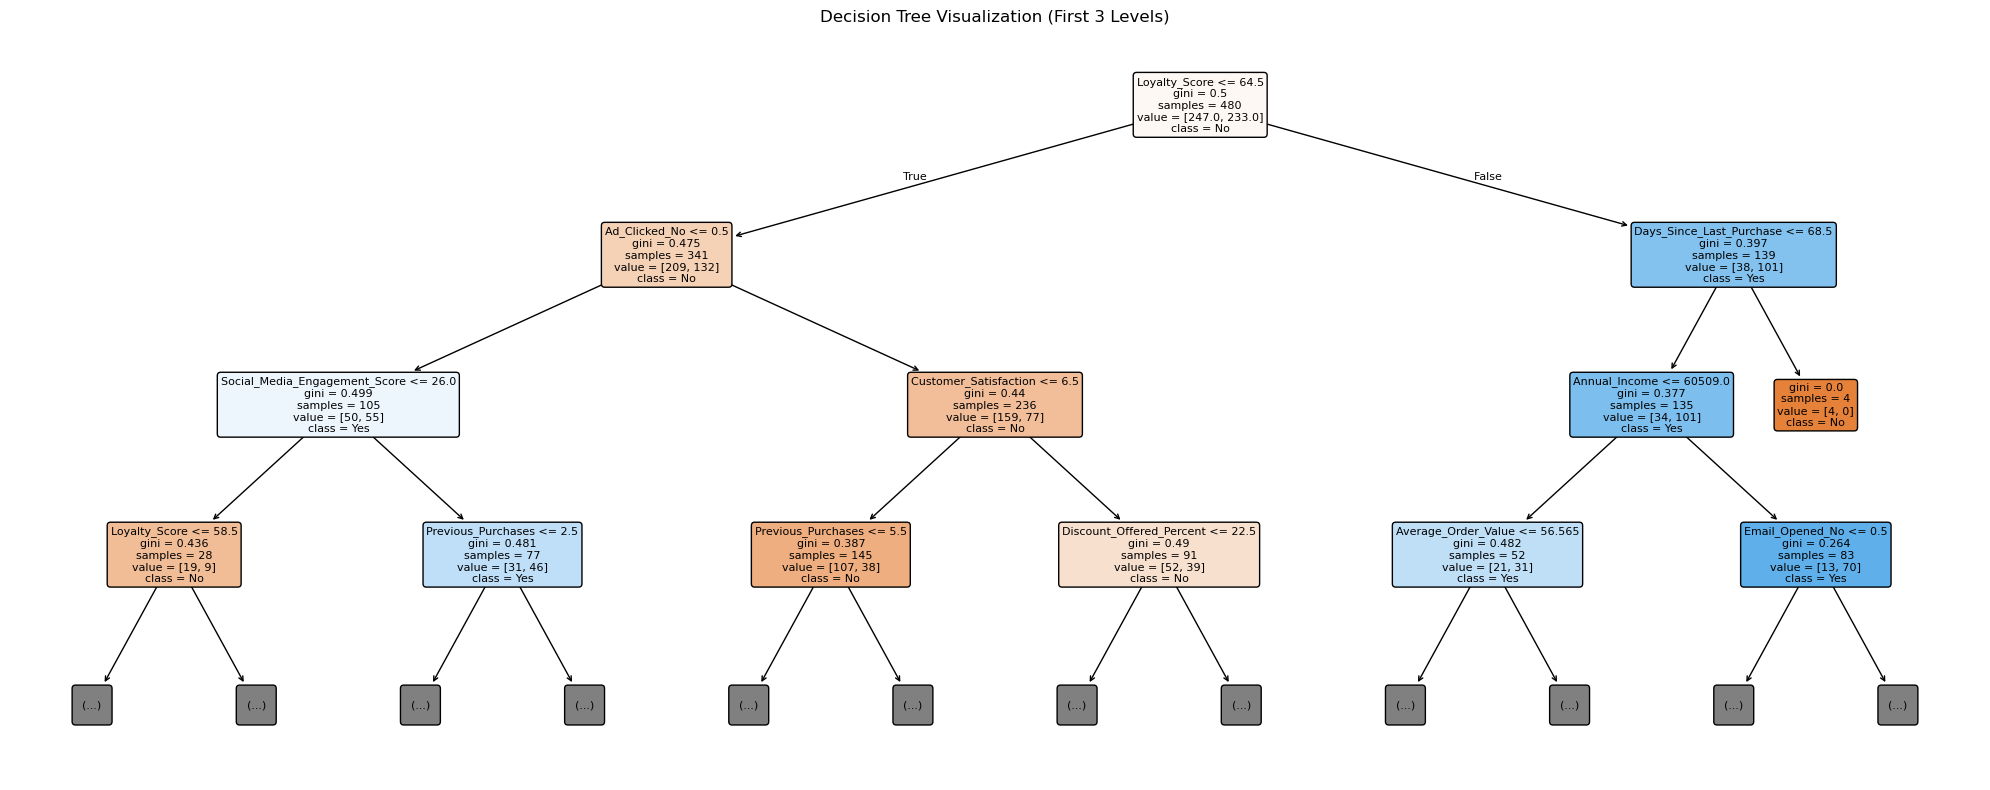

In [7]:
from sklearn.tree import plot_tree

# Visualize the Decision Tree (limited to depth 3 for readability)
plt.figure(figsize=(20, 8))
plot_tree(
    dt_model,
    max_depth=3,
    feature_names=X_encoded.columns,
    class_names=le.classes_,
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title("Decision Tree Visualization (First 3 Levels)")
plt.tight_layout()
plt.show()

Training Accuracy: 1.0000 (100.0%)
Testing Accuracy:  0.5250 (52.5%)
Gap:               47.5 percentage points


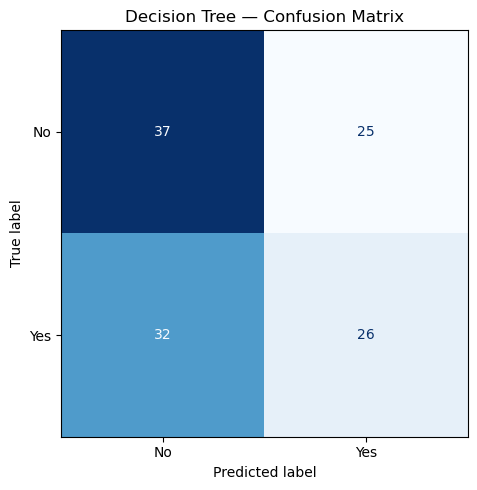

True Negatives  (TN): 37
False Positives (FP): 25
False Negatives (FN): 32
True Positives  (TP): 26

Classification Report
--------------------------------------------------
              precision    recall  f1-score   support

          No       0.54      0.60      0.56        62
         Yes       0.51      0.45      0.48        58

    accuracy                           0.53       120
   macro avg       0.52      0.52      0.52       120
weighted avg       0.52      0.53      0.52       120

Summary (Yes class):
  Accuracy  : 0.5250
  Precision : 0.5098
  Recall    : 0.4483
  F1-Score  : 0.4771


In [8]:
from sklearn.metrics import (accuracy_score, confusion_matrix, ConfusionMatrixDisplay,
                             classification_report, precision_score, recall_score, f1_score)

# Predict on training and testing sets
y_train_pred = dt_model.predict(X_train)
y_test_pred  = dt_model.predict(X_test)

# Training and testing accuracy
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy  = accuracy_score(y_test,  y_test_pred)

print("Training Accuracy: {:.4f} ({:.1f}%)".format(train_accuracy, train_accuracy * 100))
print("Testing Accuracy:  {:.4f} ({:.1f}%)".format(test_accuracy,  test_accuracy  * 100))
print("Gap:               {:.1f} percentage points".format((train_accuracy - test_accuracy) * 100))

# Confusion matrix
cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Decision Tree — Confusion Matrix")
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives  (TN): {tn}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")
print(f"True Positives  (TP): {tp}")

# Classification report
print("\nClassification Report")
print("-" * 50)
print(classification_report(y_test, y_test_pred, target_names=le.classes_))

precision = precision_score(y_test, y_test_pred)
recall    = recall_score(y_test, y_test_pred)
f1        = f1_score(y_test, y_test_pred)

print("Summary (Yes class):")
print(f"  Accuracy  : {test_accuracy:.4f}")
print(f"  Precision : {precision:.4f}")
print(f"  Recall    : {recall:.4f}")
print(f"  F1-Score  : {f1:.4f}")

In [9]:
# Overfitting check
print("Overfitting Analysis")
print("-" * 50)
print(f"Training Accuracy : {train_accuracy:.4f}")
print(f"Testing Accuracy  : {test_accuracy:.4f}")
print(f"Difference        : {train_accuracy - test_accuracy:.4f}")
print()
print("The model is OVERFITTING.")
print(f"Training accuracy is {train_accuracy*100:.1f}% but testing accuracy is only {test_accuracy*100:.1f}%.")
print(f"A gap of {(train_accuracy - test_accuracy)*100:.1f} percentage points means the tree memorized the")
print("training data and does not generalize well to new customers.")
print("Applying max_depth or min_samples_leaf would reduce overfitting.")

Overfitting Analysis
--------------------------------------------------
Training Accuracy : 1.0000
Testing Accuracy  : 0.5250
Difference        : 0.4750

The model is OVERFITTING.
Training accuracy is 100.0% but testing accuracy is only 52.5%.
A gap of 47.5 percentage points means the tree memorized the
training data and does not generalize well to new customers.
Applying max_depth or min_samples_leaf would reduce overfitting.


In [10]:
# Train a simpler Decision Tree with max_depth = 4
dt_simple = DecisionTreeClassifier(random_state=42, max_depth=4)
dt_simple.fit(X_train, y_train)

simple_train_acc = accuracy_score(y_train, dt_simple.predict(X_train))
simple_test_acc  = accuracy_score(y_test,  dt_simple.predict(X_test))

print("Simpler Decision Tree (max_depth=4)")
print("-" * 50)
print(f"Training Accuracy : {simple_train_acc:.4f} ({simple_train_acc*100:.1f}%)")
print(f"Testing Accuracy  : {simple_test_acc:.4f}  ({simple_test_acc*100:.1f}%)")
print(f"Gap               : {(simple_train_acc - simple_test_acc)*100:.1f} percentage points")

Simpler Decision Tree (max_depth=4)
--------------------------------------------------
Training Accuracy : 0.7292 (72.9%)
Testing Accuracy  : 0.5833  (58.3%)
Gap               : 14.6 percentage points


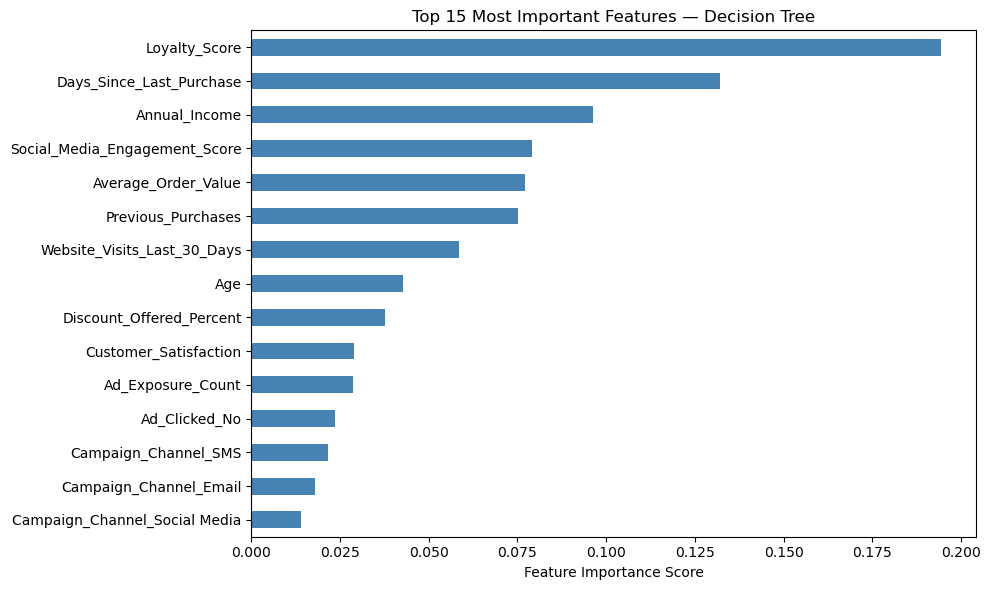


Top 15 Feature Importances:


,Feature,Importance
0,Loyalty_Score,0.194408
1,Days_Since_Last_Purchase,0.132132
2,Annual_Income,0.096294
3,Social_Media_Engagement_Score,0.079226
4,Average_Order_Value,0.077023
5,Previous_Purchases,0.075138
6,Website_Visits_Last_30_Days,0.058547
7,Age,0.042768
8,Discount_Offered_Percent,0.037715
9,Customer_Satisfaction,0.028905


In [11]:
# Extract and visualize top feature importances
importances = pd.Series(dt_model.feature_importances_, index=X_encoded.columns)
importances = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
importances.plot(kind="barh", color="steelblue")
plt.gca().invert_yaxis()
plt.title("Top 15 Most Important Features — Decision Tree")
plt.xlabel("Feature Importance Score")
plt.tight_layout()
plt.show()

print("\nTop 15 Feature Importances:")
display(importances.reset_index().rename(columns={"index": "Feature", 0: "Importance"}))

## Task 4: Business Interpretation of Model Results

**How well did the Decision Tree model perform?**

The model achieved a testing accuracy of 52.5% (63 out of 120 test records
correctly classified). The precision for the "Yes" class is 50.98%, recall
is 44.83%, and F1-score is 47.71%. This performance is barely above random
guessing for a balanced dataset, meaning the model has very limited ability
to reliably identify customers who will convert. When tree depth was limited
to max_depth=4, testing accuracy improved to 58.3% with a much smaller gap,
showing that a simpler tree generalizes better.

**Is there a large difference between training accuracy and testing accuracy?**

Yes — the gap is extremely large. The unconstrained model achieved 100%
training accuracy but only 52.5% testing accuracy, a difference of 47.5
percentage points. The tree memorized every training record perfectly but
fails to generalize to new customers it has not seen before.

**Does the model show signs of overfitting? Why or why not?**

Yes, severely. Without constraints, the tree grew 16 levels deep with 108
leaves — far too complex for a dataset of 600 records. It memorized training
patterns instead of learning generalizable rules. When max_depth was limited
to 4, the gap dropped to 14.6 percentage points and testing accuracy improved,
confirming that the original tree was overfitting.

**Which evaluation metric is most important for this business problem?**

According to the business plan, F1-score is the recommended primary metric
because AdVantage Growth Studio wants to balance two risks equally: wasting
budget on customers who will not convert (false positives) and missing
customers who would have converted (false negatives). With an F1-score of
only 47.71% for the "Yes" class, the model currently performs poorly on
both fronts.

**What do false positives mean in this business context?**

A false positive means the model predicted a customer would convert, but
they did not. There were 25 false positives in the test set. For AdVantage
Growth Studio, this means 25 customers received follow-up marketing —
emails, retargeting ads, or discount reminders — that were wasted on
customers who had no intention of buying. This wastes the client's
advertising budget and may annoy customers with irrelevant messages.

**What do false negatives mean in this business context?**

A false negative means the model predicted a customer would not convert,
but they actually would have. There were 32 false negatives in the test set.
For AdVantage Growth Studio, this means 32 customers who were ready to buy
never received a follow-up. The client missed potential revenue, and those
customers may have converted with a timely discount reminder or personalized
message.

**Which features were most important in the Decision Tree model?**

The top features were:
1. Loyalty_Score (19.4%) — the strongest predictor of conversion
2. Days_Since_Last_Purchase (13.2%) — recency of last purchase signals intent
3. Annual_Income (9.6%) — income level relates to purchasing power
4. Social_Media_Engagement_Score (7.9%) — active engagement signals interest
5. Average_Order_Value (7.7%) — higher spenders may be more likely to convert
6. Previous_Purchases (7.5%) — repeat buyers are more likely to convert again
7. Website_Visits_Last_30_Days (5.9%) — recent browsing signals purchase intent

**How can these important features help the business make better decisions?**

Loyalty_Score is the top predictor — the agency should prioritize loyal
customers in every campaign as they are most likely to respond positively.

Days_Since_Last_Purchase reveals customer recency — customers who purchased
recently are still engaged, while those inactive for a long time may need
a reactivation campaign with a stronger incentive such as a larger discount.

Social_Media_Engagement_Score and Website_Visits_Last_30_Days together
indicate warm leads — customers actively engaging with content and browsing
the website are showing purchase intent and should receive immediate follow-up.

Previous_Purchases confirms that repeat buyers are valuable — the agency
should design loyalty rewards and exclusive offers to keep these customers
converting regularly.

**What is one possible limitation or bias in the model or dataset?**

The dataset is synthetic and contains only 600 records, which is insufficient
for a reliable production model. Annual_Income and Region may introduce
fairness concerns. If the model associates higher income with higher conversion
probability, lower-income customers may be systematically excluded from
campaign targeting — even if they are genuinely interested and would convert
given the right offer.

**Why should human judgment still be used when making business decisions based on model results?**

A model with 52.5% testing accuracy is performing only marginally better than
random chance. Relying on it alone to allocate campaign budgets or target
customers would be a serious mistake. Marketing managers must review model
outputs, check whether recommendations make business sense, and consider
factors the model cannot capture — such as seasonal trends, brand sentiment,
customer service history, and campaign budget constraints. Human oversight
also ensures that targeting decisions are fair, ethical, and aligned with
the client's brand values and customer relationships.

## Limitations of Tree-Based Models

While Decision Trees are useful and easy to interpret, they have several
important limitations that should be considered before using them in a
real business setting:

- **Overfitting:** Without constraints, Decision Trees can grow too deep
  and memorize the training data, leading to poor performance on new data.

- **Instability:** Small changes in the training data can result in a
  completely different tree structure, making the model unstable.

- **Imbalanced classes:** When one class has significantly more records
  than the other, the tree may be biased toward predicting the majority
  class more often.

- **Limited generalization:** A Decision Tree trained on a small or
  synthetic dataset may not capture the full complexity of real customer
  behavior.

- **No probability calibration:** The model predicts a class label but
  does not always produce well-calibrated probability estimates, which
  limits its use in risk-scored targeting.

---

## Responsible AI Reflection

Machine learning models used in marketing can affect real customers and
must be developed and applied responsibly.

- **Fairness:** Features like Annual_Income, Age, and Region may cause
  the model to systematically disadvantage certain customer groups. The
  agency must check whether campaign recommendations are being made fairly
  across all demographics.

- **Transparency:** The Decision Tree is interpretable, which is an
  advantage — managers can follow the decision rules. However, the model
  should still be reviewed by qualified staff before use.

- **Human oversight:** Model outputs should support human decision-making,
  not replace it. Customer consent, campaign ethics, and brand values
  cannot be fully captured by a machine learning model.

- **Data quality:** This dataset is synthetic and simplified. A real
  deployment would require higher-quality data, ongoing monitoring for
  bias, and regular model updates.

---

## Final Conclusion

This notebook built and evaluated a Decision Tree classification model to
predict whether customers are likely to convert after receiving a marketing
campaign from AdVantage Growth Studio.

The model achieved a testing accuracy of 52.5%, with precision of 50.98%,
recall of 44.83%, and F1-score of 47.71% for the "Yes" class. The
unconstrained tree showed severe overfitting — 100% training accuracy versus
52.5% testing accuracy. When tree depth was limited to 4, testing accuracy
improved to 58.3% with a much smaller gap, demonstrating the importance of
controlling model complexity.

The most important predictors were Loyalty_Score, Days_Since_Last_Purchase,
Annual_Income, Social_Media_Engagement_Score, and Previous_Purchases. These
features reflect customer loyalty, purchase recency, and engagement — all
strong signals of conversion likelihood.

From a business perspective, the model provides a useful starting point for
campaign targeting but should not be used in isolation. Human review,
fairness checks, and ethical oversight are all necessary before launching
any campaign based on model results. A more robust deployment would benefit
from a larger real-world dataset and a more powerful algorithm such as
Random Forest or Gradient Boosting.

---
